# Algoritmos de Búsqueda en Grafos 

## Introducción

En el ámbito de la optimización de flujo en redes, los algoritmos de búsqueda en grafos son herramientas fundamentales para explorar y analizar estructuras complejas. En esta clase, profundizaremos en dos algoritmos esenciales:

- **Búsqueda en Anchura (Breadth-First Search, BFS)**
- **Búsqueda en Profundidad (Depth-First Search, DFS)**




**Conceptos Fundamentales de Grafos (Recordemos)**

Un **grafo** $ G = (V, E) $ es una estructura compuesta por un conjunto de **vértices** $ V $ y un conjunto de **aristas** $ E $ que conectan pares de vértices. Los grafos pueden ser **dirigidos** o **no dirigidos**, y pueden contener pesos o capacidades en sus aristas, lo cual es crucial en problemas de flujo.

### Definiciones Clave

- **Camino**: Secuencia de vértices donde cada par consecutivo está conectado por una arista.
- **Ciclo**: Camino donde el primer y último vértice son el mismo.
- **Conectividad**: Un grafo es **conexo** si existe un camino entre cualquier par de vértices.S


## 1. Algoritmo de búsqueda en Gráfos

Dado un grafo $ G = (V, A) $ y un nodo fuente $ s \in V $, queremos verificar si todos los nodos $ \in V $ pueden ser alcanzados desde $ s $ usando solo los arcos $ \in A $. Esencialmente, queremos la lista de todos los nodos alcanzables desde $ s $ y posiblemente también el camino desde $ s $ a cada nodo. Como se vio en clase, este conjunto de caminos debe formar un árbol, lo cual se deduce de la demostración de corrección de la formulación de Programación Lineal (LP) del problema de camino más corto de una sola fuente.


### 1.1 Algoritmo genérico de búsqueda

Un algoritmo genérico de búsqueda comienza con un nodo especial, lo designa como la raíz de un árbol y lo coloca en una lista $L$. El algoritmo selecciona en cada iteración un nodo de la lista y encuentra un vecino (vecino saliente para un grafo dirigido), si existe, y lo agrega a la lista. El proceso continúa hasta que se han visitado todos los nodos o se han escaneado todas las aristas (arcos). El mecanismo de selección a partir de la lista diferencia entre los algoritmos de búsqueda.

En el procedimiento que se muestra a continuación, $ N_E(v) $ es un vecino del nodo $ v $ en el grafo inducido por el conjunto de aristas $ E $. Para un grafo dirigido, el mismo algoritmo se aplica con $ N_A^+(v) $ refiriéndose a un vecino saliente de $ v $ con respecto al conjunto de arcos $ A $.

**Pseudocódigo para un algoritmo genérico de búsqueda**


1. $ L \gets \{\text{raíz}\} $, $ V \gets V \setminus \{\text{raíz}\} $;
2. Mientras $ L \neq \emptyset $:
   - Seleccionar $ v \in L $ (usar la regla de selección);
   - Si existe $ N_E(v) = u $, $ u \in V \setminus L $:
     - $ L \gets L \cup \{u\} $;
     - $ V \gets V \setminus \{u\} $;
     - $ E \gets E \setminus \{[v, u]\} $;
   - Si no:
     - $ L \gets L \setminus \{v\} $;
3. Fin mientras.


Dos métodos básicos que se utilizan para definir el mecanismo de selección son la **Búsqueda en Anchura (BFS)** y la **Búsqueda en Profundidad (DFS)**.



<a id="2"></a>
## 2. Búsqueda en Anchura (BFS)


La búsqueda en anchura emplea una estrategia de **primero en entrar, primero en salir** (FIFO) y generalmente se implementa usando una cola. Para obtener el pseudocódigo de BFS, solo necesitamos modificar el pseudocódigo del algoritmo de búsqueda genérico, de modo que cuando eliminamos la arista $(u, v)$ de $ L $, la eliminemos desde el inicio de $ L $.

En la búsqueda en anchura, el grafo se explora de manera exhaustiva; es decir, todos los vecinos previamente no escaneados de un nodo en particular se etiquetan y se añaden al final de la lista de alcanzabilidad $ L $, y luego se añaden los vecinos previamente no escaneados del siguiente nodo en la lista, y así sucesivamente.

Es importante notar que el árbol BFS no es único y depende del orden en el que se visiten los vecinos. No todas las aristas del grafo original están representadas en el árbol. Sin embargo, sabemos que el grafo original no puede contener ninguna arista que conecte dos niveles no consecutivos en el árbol. Por nivel, nos referimos a un conjunto de nodos tal que el número de aristas que conectan cada nodo con la raíz del árbol es el mismo.

#### Teorema (Propiedad del BFS 1). El nivel de un nodo, $ d(v) $, es la distancia de $ s $ a $ v $.



**Pseudocódigo para Búsqueda en Anchura (BFS)**

1. $ L \gets \{\text{raíz}\} $, $ V \gets V \setminus \{\text{raíz}\} $;
2. Mientras $ L \neq \emptyset $:
   - Seleccionar el primer nodo $ v $ de $ L $;
   - Para cada vecino no explorado $ u $ de $ v $ (i.e., $ u \in V $):
     - Añadir $ u $ al final de $ L $;
     - $ V \gets V \setminus \{u\} $;
   - Eliminar $ v $ de $ L $;
3. Fin mientras.




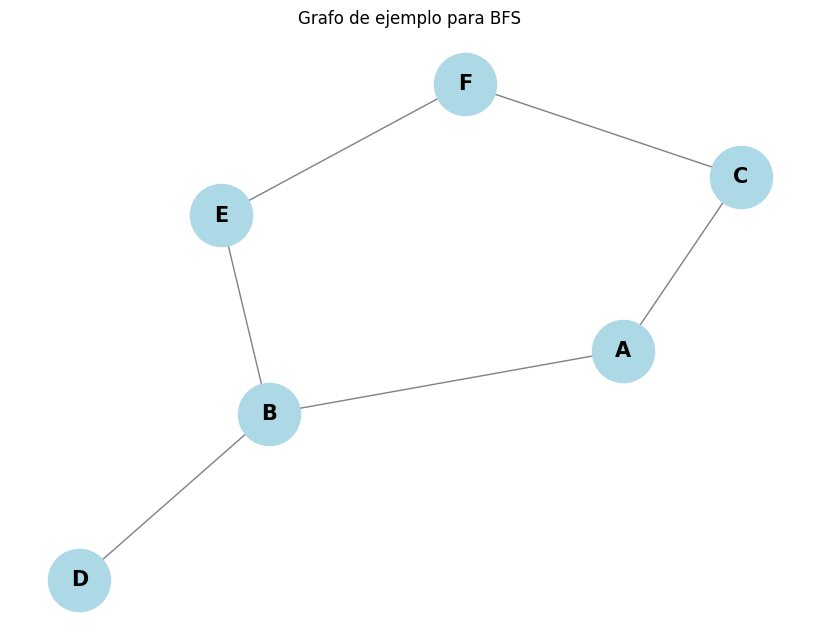

In [2]:
import matplotlib.pyplot as plt
import networkx as nx

# Definimos el grafo de ejemplo
graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E']
}

# Crear un grafo usando NetworkX
G = nx.Graph()

# Agregar nodos y aristas desde el diccionario
for node, neighbors in graph.items():
    for neighbor in neighbors:
        G.add_edge(node, neighbor)

# Dibujar el grafo
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G)  # Layout para organizar el grafo
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=15, font_weight='bold', edge_color='gray')

plt.title("Grafo de ejemplo para BFS")
plt.show()

In [1]:
from collections import deque

def bfs(graph, start):
    # Creamos una cola FIFO con deque y agregamos el nodo de inicio
    queue = deque([start])
    # Mantendremos un conjunto de nodos visitados para evitar ciclos
    visited = set([start])
    
    # Mostrar el estado inicial
    print(f"Inicializando BFS con el nodo raíz: {start}")
    print(f"Cola inicial: {list(queue)}")
    print(f"Nodos visitados inicialmente: {visited}")
    print("-" * 40)
    
    while queue:
        # Sacamos el primer nodo de la cola
        node = queue.popleft()
        print(f"Explorando nodo: {node}")
        
        # Para cada vecino no visitado, lo marcamos como visitado y lo agregamos a la cola
        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
                print(f"Vecino {neighbor} descubierto y agregado a la cola.")
        
        # Mostramos el estado de la cola y los nodos visitados en cada paso
        print(f"Cola actual: {list(queue)}")
        print(f"Nodos visitados hasta ahora: {visited}")
        print("-" * 40)

# Llamamos a la función bfs con la red de ejemplo
bfs(graph, 'A')


Inicializando BFS con el nodo raíz: A
Cola inicial: ['A']
Nodos visitados inicialmente: {'A'}
----------------------------------------
Explorando nodo: A
Vecino B descubierto y agregado a la cola.
Vecino C descubierto y agregado a la cola.
Cola actual: ['B', 'C']
Nodos visitados hasta ahora: {'A', 'C', 'B'}
----------------------------------------
Explorando nodo: B
Vecino D descubierto y agregado a la cola.
Vecino E descubierto y agregado a la cola.
Cola actual: ['C', 'D', 'E']
Nodos visitados hasta ahora: {'A', 'D', 'E', 'C', 'B'}
----------------------------------------
Explorando nodo: C
Vecino F descubierto y agregado a la cola.
Cola actual: ['D', 'E', 'F']
Nodos visitados hasta ahora: {'F', 'A', 'D', 'E', 'C', 'B'}
----------------------------------------
Explorando nodo: D
Cola actual: ['E', 'F']
Nodos visitados hasta ahora: {'F', 'A', 'D', 'E', 'C', 'B'}
----------------------------------------
Explorando nodo: E
Cola actual: ['F']
Nodos visitados hasta ahora: {'F', 'A', 'D', '


## 3. Búsqueda en Profundidad (DFS)

La búsqueda en profundidad emplea una estrategia de **último en entrar, primero en salir** (LIFO) y generalmente se implementa utilizando una pila. Para obtener el pseudocódigo de la búsqueda en profundidad (DFS), solo necesitamos modificar el pseudocódigo de la búsqueda genérica de manera que, cuando eliminamos la arista $(u, v)$ de $ L $, la eliminamos desde el **final** de $ L $.

En la búsqueda en profundidad, se busca un vecino previamente no escaneado de un nodo dado. Si se encuentra tal nodo, se añade al final de la lista y se explora desde allí; de lo contrario, el nodo original se elimina de la lista, y ahora escaneamos el nodo que está al final de la lista.

E

#### Propiedades de DFS

- **Complejidad Temporal**: $ O(V + E) $
- **Utiliza una estructura de datos tipo pila (LIFO) o recursión.**
- **Puede ser utilizado para clasificaciones topológicas en grafos dirigidos acíclicos.**


**Pseudocódigo para Búsqueda en Profundidad (DFS)**

1. $ L \gets \{\text{raíz}\} $, $ V \gets V \setminus \{\text{raíz}\} $;
2. Mientras $ L \neq \emptyset $:
   - Seleccionar el último nodo $ v $ de $ L $ (es decir, desde el final de $ L $);
   - Si $ v $ tiene algún vecino no explorado $ u $ (i.e., $ u \in V $):
     - Añadir $ u $ al final de $ L $;
     - $ V \gets V \setminus \{u\} $;
   - Si no hay vecinos no explorados:
     - Eliminar $ v $ de $ L $;
3. Fin mientras.



In [3]:
def dfs(graph, start):
    # Inicializamos una pila con el nodo de inicio
    stack = [start]
    # Mantendremos un conjunto de nodos visitados
    visited = set([start])
    
    # Mostrar el estado inicial
    print(f"Inicializando DFS con el nodo raíz: {start}")
    print(f"Pila inicial: {stack}")
    print(f"Nodos visitados inicialmente: {visited}")
    print("-" * 40)
    
    while stack:
        # Tomamos el último nodo de la pila (LIFO)
        node = stack[-1]
        print(f"Explorando nodo: {node}")
        
        # Buscamos un vecino no visitado
        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                stack.append(neighbor)
                print(f"Vecino {neighbor} descubierto y agregado a la pila.")
                break
        else:
            # Si no encontramos vecinos no explorados, retiramos el nodo de la pila
            stack.pop()
            print(f"Nodo {node} completamente explorado, retirado de la pila.")
        
        # Mostramos el estado de la pila y los nodos visitados en cada paso
        print(f"Pila actual: {stack}")
        print(f"Nodos visitados hasta ahora: {visited}")
        print("-" * 40)

# Llamamos a la función dfs con la red de ejemplo
#dfs(graph, 'A')

Inicializando DFS con el nodo raíz: A
Pila inicial: ['A']
Nodos visitados inicialmente: {'A'}
----------------------------------------
Explorando nodo: A
Vecino B descubierto y agregado a la pila.
Pila actual: ['A', 'B']
Nodos visitados hasta ahora: {'A', 'B'}
----------------------------------------
Explorando nodo: B
Vecino D descubierto y agregado a la pila.
Pila actual: ['A', 'B', 'D']
Nodos visitados hasta ahora: {'A', 'D', 'B'}
----------------------------------------
Explorando nodo: D
Nodo D completamente explorado, retirado de la pila.
Pila actual: ['A', 'B']
Nodos visitados hasta ahora: {'A', 'D', 'B'}
----------------------------------------
Explorando nodo: B
Vecino E descubierto y agregado a la pila.
Pila actual: ['A', 'B', 'E']
Nodos visitados hasta ahora: {'A', 'D', 'E', 'B'}
----------------------------------------
Explorando nodo: E
Vecino F descubierto y agregado a la pila.
Pila actual: ['A', 'B', 'E', 'F']
Nodos visitados hasta ahora: {'F', 'A', 'D', 'E', 'B'}
------

### Aplicaciones 

#### Propiedad fundamental de un grafo bipartito:


Un grafo es **bipartito** si su conjunto de nodos \( V \) puede ser particionado en dos subconjuntos de tal manera que todas las aristas o arcos en \( E/A \) tengan un punto final en cada uno de los dos conjuntos.

Para verificar si un grafo es bipartito, podemos utilizar una búsqueda en anchura (BFS) desde un nodo arbitrario. Si, durante la exploración, encontramos una arista entre dos nodos que se encuentran en el mismo nivel (en el mismo subconjunto de la partición), esto indica la existencia de un ciclo impar. Dado que un grafo bipartito no puede contener ciclos impares, este grafo no sería bipartito.

De manera similar, podemos detectar un ciclo impar en un grafo al observar si hay una arista entre un nodo y uno de sus descendientes que se encuentra en el siguiente nivel. También podemos asignar dos colores alternos a los nodos mientras recorremos el grafo. Si encontramos una arista que conecta dos nodos del mismo color, esto indica la presencia de un ciclo impar, y por lo tanto, el grafo no es bipartito.


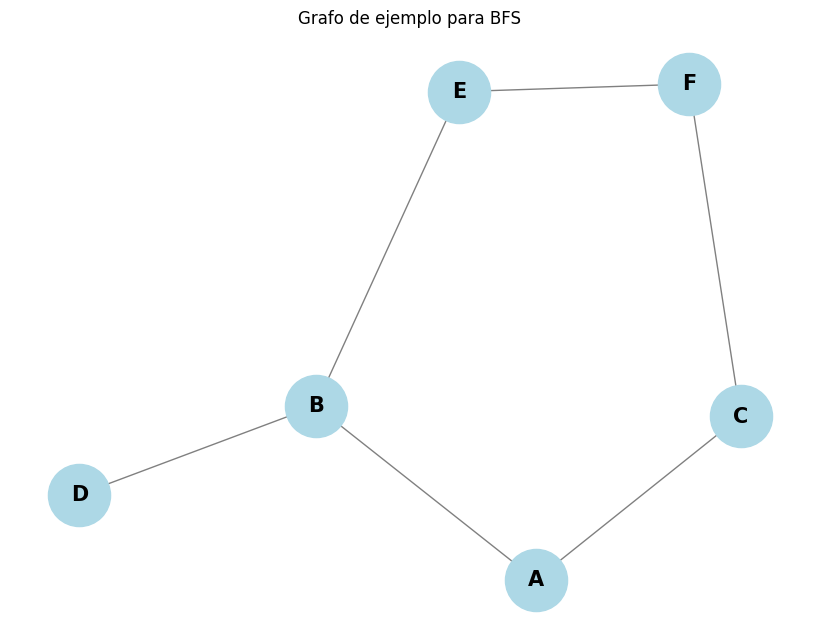

In [4]:
# Definimos el grafo de ejemplo
graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E']
}

# Crear un grafo usando NetworkX
G = nx.Graph()

# Agregar nodos y aristas desde el diccionario
for node, neighbors in graph.items():
    for neighbor in neighbors:
        G.add_edge(node, neighbor)

# Dibujar el grafo
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G)  # Layout para organizar el grafo
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=15, font_weight='bold', edge_color='gray')

plt.title("Grafo de ejemplo para DFS")
plt.show()

In [5]:
from collections import deque

# Definimos el grafo como un diccionario (cada nodo tiene una lista de vecinos)
graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E']
}

def is_bipartite(graph, start):
    # Usaremos un diccionario para asignar colores a los nodos
    color = {}
    # Inicializamos una cola para BFS
    queue = deque([start])
    # Asignamos el primer color al nodo inicial
    color[start] = 0  # 0 = rojo, 1 = azul
    
    while queue:
        node = queue.popleft()
        current_color = color[node]
        next_color = 1 - current_color  # Alternar el color
        
        for neighbor in graph[node]:
            if neighbor not in color:
                # Si el vecino no tiene color, lo coloreamos con el color opuesto
                color[neighbor] = next_color
                queue.append(neighbor)
            elif color[neighbor] == current_color:
                # Si el vecino tiene el mismo color, el grafo no es bipartito
                return False
    
    return True

# Llamamos a la función is_bipartite con la red de ejemplo
result = is_bipartite(graph, 'A')
if result:
    print("El grafo es bipartito.")
else:
    print("El grafo NO es bipartito.")


El grafo NO es bipartito.


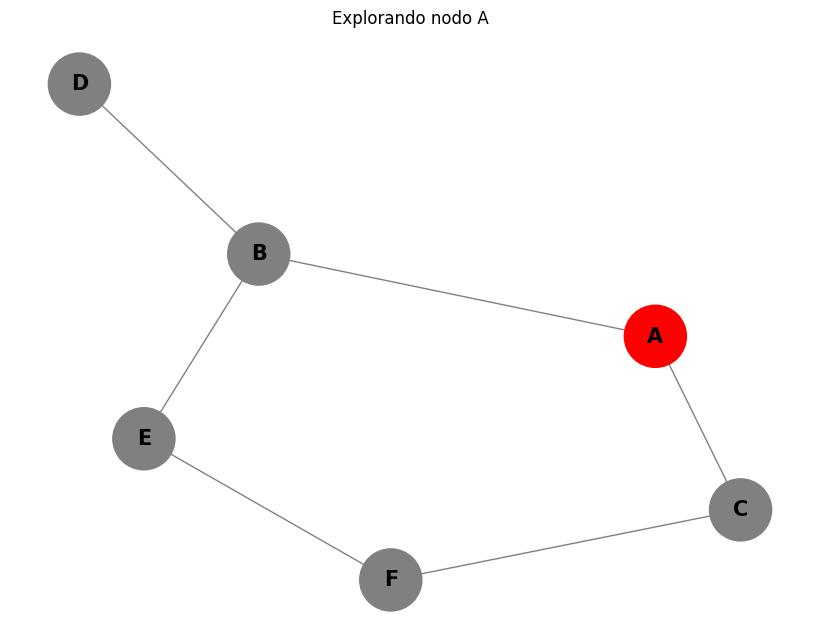

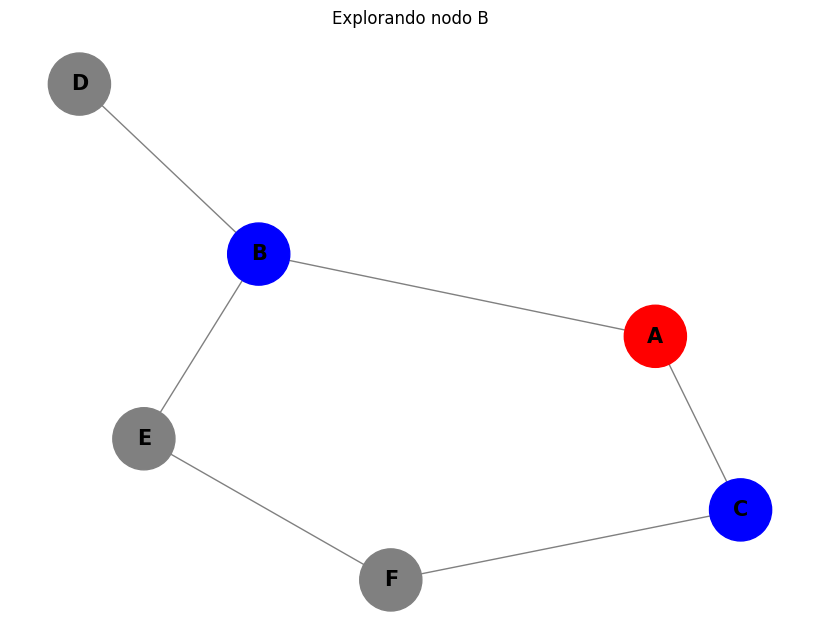

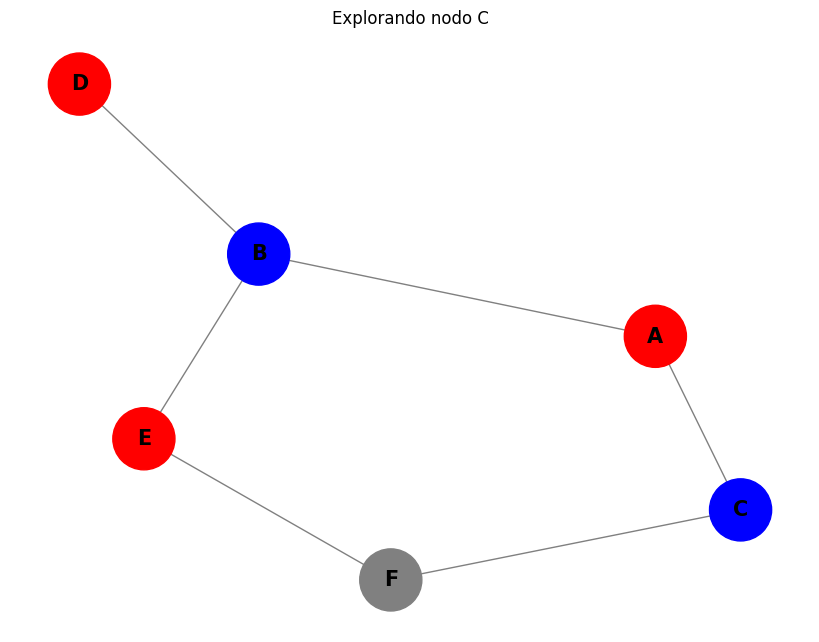

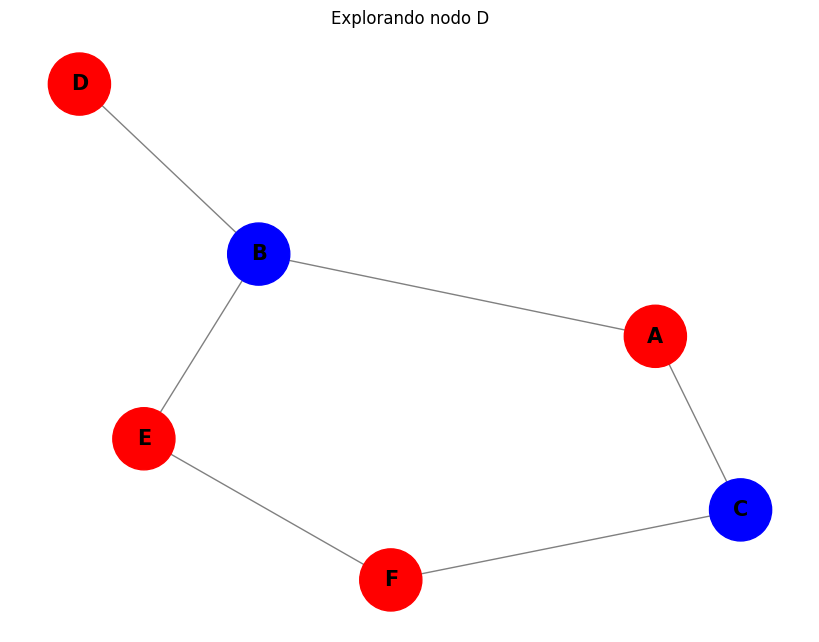

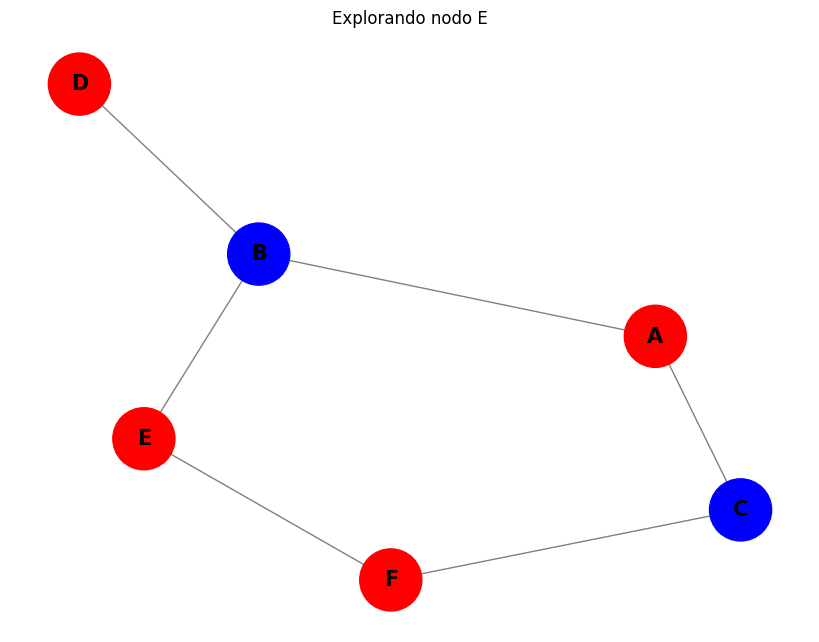

El grafo NO es bipartito. Conflicto encontrado entre E y F


In [6]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque

# Definimos el grafo como un diccionario (cada nodo tiene una lista de vecinos)
graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E']
}

def is_bipartite(graph, start):
    # Creamos un grafo de networkx
    G = nx.Graph()
    for node, neighbors in graph.items():
        for neighbor in neighbors:
            G.add_edge(node, neighbor)

    # Usamos un diccionario para asignar colores a los nodos
    color = {}
    # Inicializamos una cola para BFS
    queue = deque([start])
    # Asignamos el primer color al nodo inicial
    color[start] = 0  # 0 = rojo, 1 = azul
    
    # Creamos un layout fijo para el grafo
    pos = nx.spring_layout(G)
    
    while queue:
        node = queue.popleft()
        current_color = color[node]
        next_color = 1 - current_color  # Alternar el color

        # Dibujamos el grafo en su estado actual
        plt.figure(figsize=(8, 6))
        color_map = ['red' if color.get(n) == 0 else 'blue' if color.get(n) == 1 else 'gray' for n in G.nodes]
        nx.draw(G, pos, with_labels=True, node_color=color_map, node_size=2000, font_size=15, font_weight='bold', edge_color='gray')
        plt.title(f"Explorando nodo {node}")
        plt.show()

        for neighbor in graph[node]:
            if neighbor not in color:
                # Si el vecino no tiene color, lo coloreamos con el color opuesto
                color[neighbor] = next_color
                queue.append(neighbor)
            elif color[neighbor] == current_color:
                # Si el vecino tiene el mismo color, el grafo no es bipartito
                print(f"El grafo NO es bipartito. Conflicto encontrado entre {node} y {neighbor}")
                return False

    # Dibujar el grafo final coloreado
    plt.figure(figsize=(8, 6))
    color_map = ['red' if color.get(n) == 0 else 'blue' if color.get(n) == 1 else 'gray' for n in G.nodes]
    nx.draw(G, pos, with_labels=True, node_color=color_map, node_size=2000, font_size=15, font_weight='bold', edge_color='gray')
    plt.title("Resultado final de la coloración")
    plt.show()

    return True

# Llamamos a la función is_bipartite con la red de ejemplo
result = is_bipartite(graph, 'A')
if result:
    print("El grafo es bipartito.")


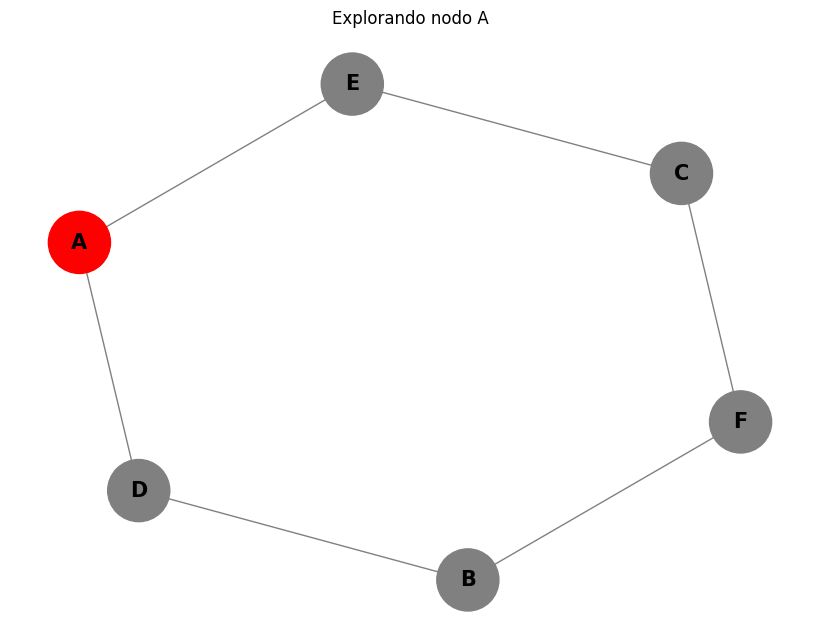

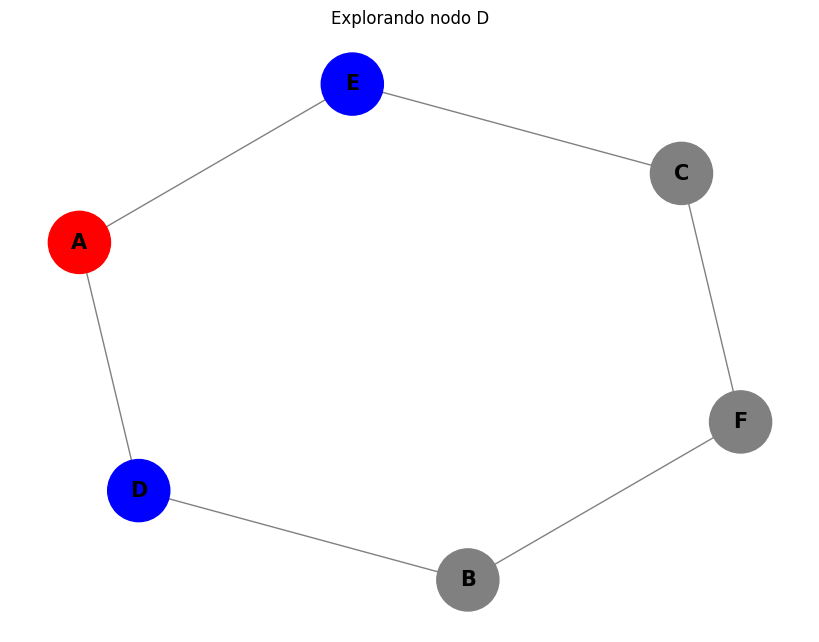

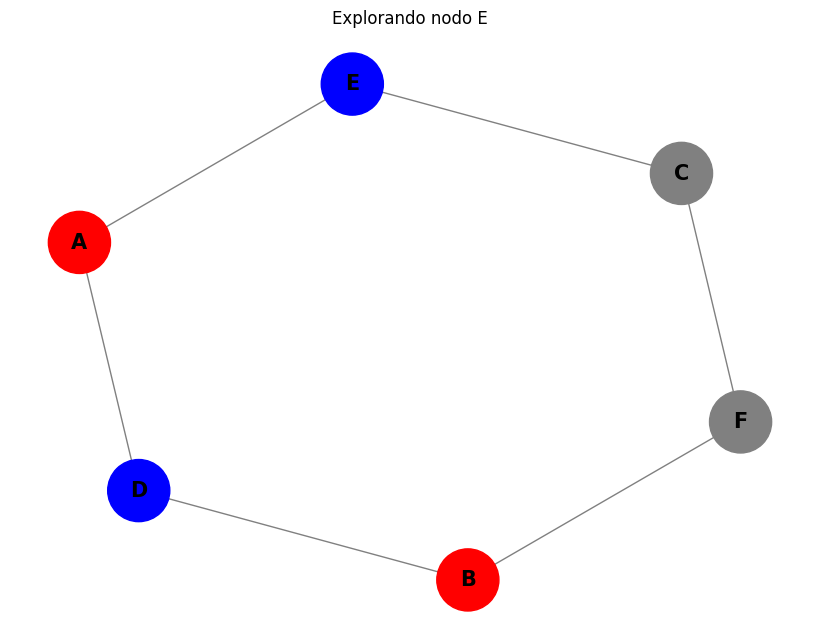

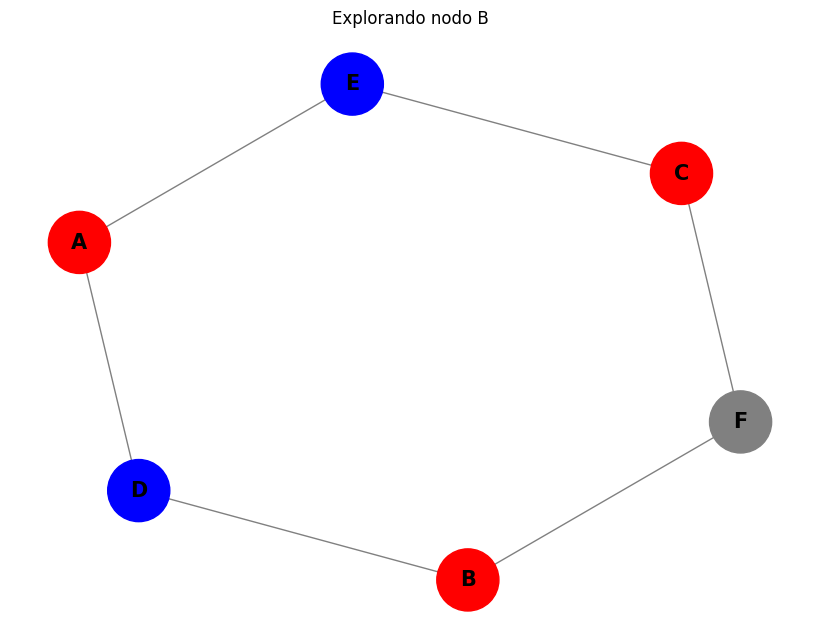

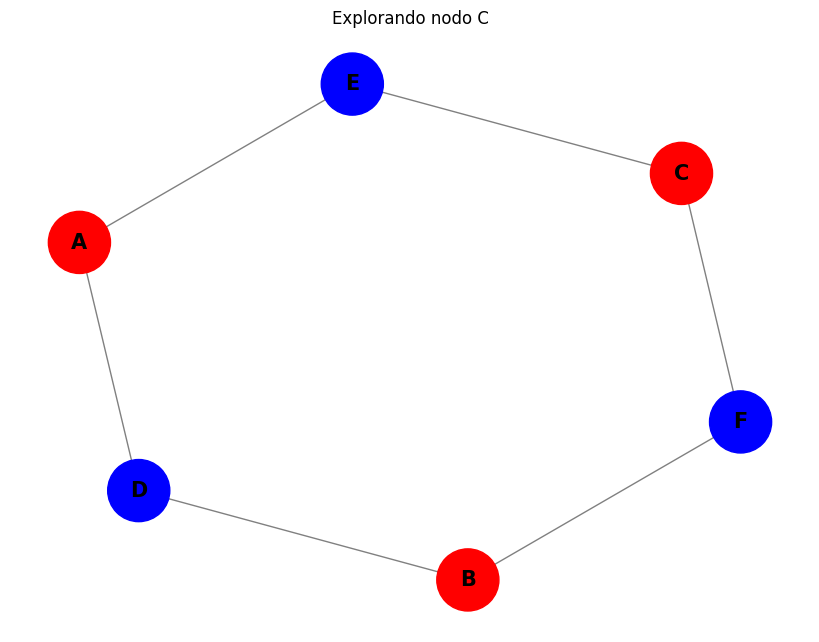

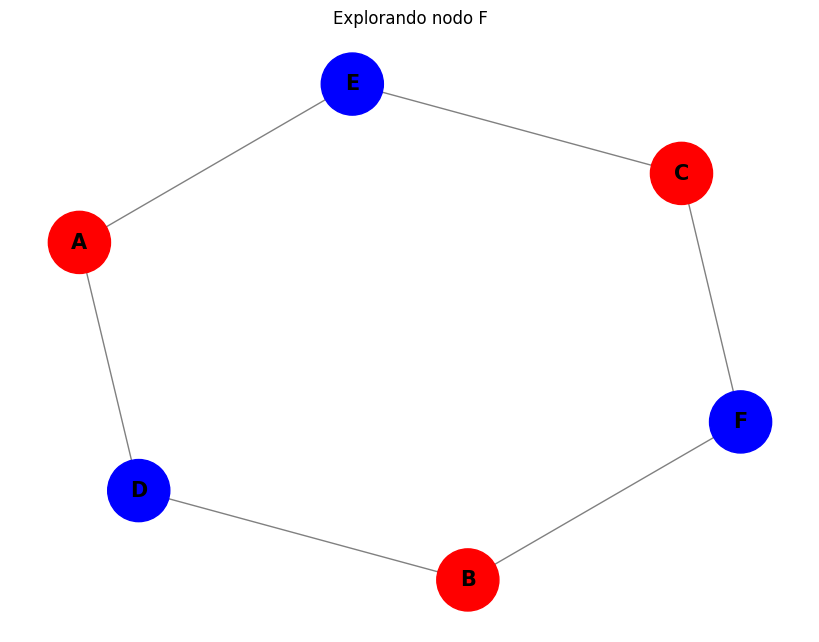

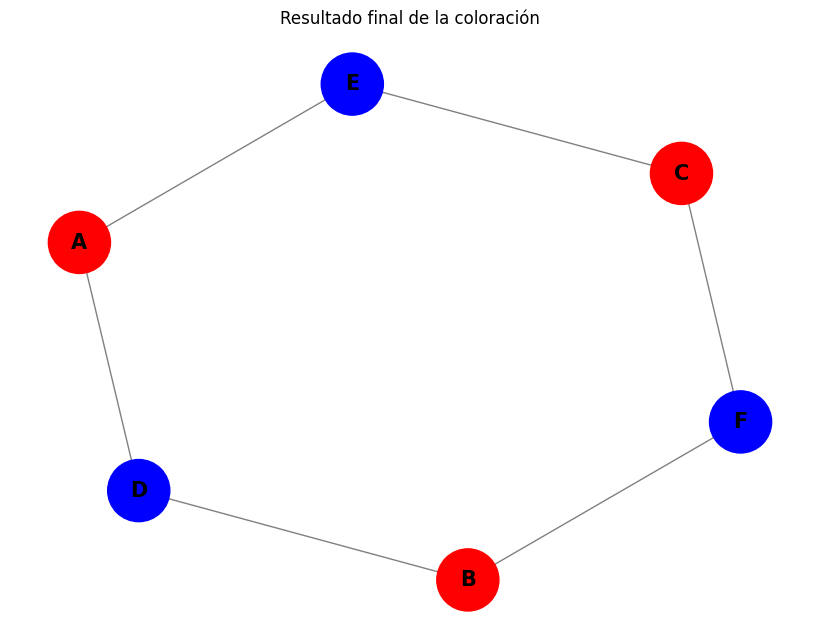

El grafo es bipartito.


In [8]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque

# Definimos un grafo bipartito como un diccionario (cada nodo tiene una lista de vecinos)
bipartite_graph = {
    'A': ['D', 'E'],
    'B': ['D', 'F'],
    'C': ['E', 'F'],
    'D': ['A', 'B'],
    'E': ['A', 'C'],
    'F': ['B', 'C']
}



# Llamamos a la función is_bipartite con el grafo bipartito de ejemplo
result = is_bipartite(bipartite_graph, 'A')
if result:
    print("El grafo es bipartito.")
else:
    print("El grafo NO es bipartito.")


#### Chequeo si un grafo es acíclico

Determinar si un grafo es **acíclico** significa verificar si el grafo no contiene ningún ciclo. Existen diferentes enfoques para determinar si un grafo es acíclico dependiendo de si estamos trabajando con un **grafo dirigido** (DAG - Directed Acyclic Graph) o un **grafo no dirigido**.

**Estrategia para grafos no dirigidos:**
En un grafo no dirigido, un ciclo ocurre si, al recorrer el grafo, encontramos un nodo que ya ha sido visitado y que no es el padre directo del nodo actual.

- **DFS** (Depth First Search) es comúnmente utilizado para detectar ciclos en grafos no dirigidos.
- Durante la exploración de un nodo, si encontramos que uno de sus vecinos ya ha sido visitado pero no es el nodo desde el cual se llegó, esto significa que hemos encontrado un ciclo.

**Estrategia para grafos dirigidos:**
En un grafo dirigido, el objetivo es verificar si hay ciclos orientados. Un ciclo ocurre si, durante la exploración, encontramos un nodo que ya está en el proceso de ser explorado (es decir, un nodo que ya está en la pila de DFS).

- Una forma común de verificar ciclos en grafos dirigidos es utilizando **DFS** y manteniendo dos conjuntos:
  - **Visitados**: nodos que ya han sido completamente procesados.
  - **En proceso**: nodos que están en el proceso de ser explorados. Si encontramos un nodo que está en el conjunto "en proceso", significa que hay un ciclo.


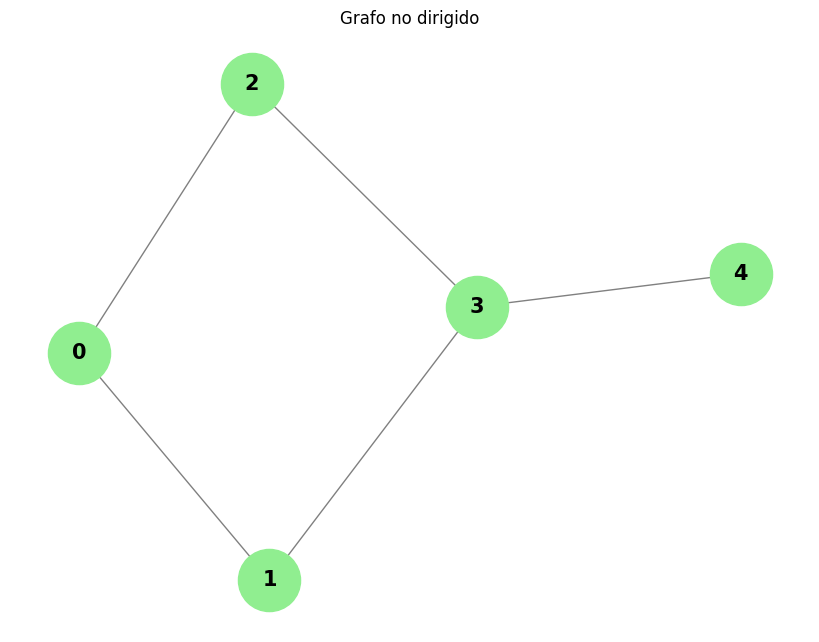

In [9]:
# Grafo no dirigido
graph = {
    0: [1, 2],
    1: [0, 3],
    2: [0, 3],
    3: [1, 2, 4],
    4: [3]
}

# Crear el grafo en NetworkX
G = nx.Graph()

# Añadir nodos y aristas al grafo
for node, neighbors in graph.items():
    for neighbor in neighbors:
        G.add_edge(node, neighbor)

# Dibujar el grafo no dirigido
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G)  # Layout para organizar el grafo
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=2000, font_size=15, font_weight='bold', edge_color='gray')
plt.title("Grafo no dirigido")
plt.show()

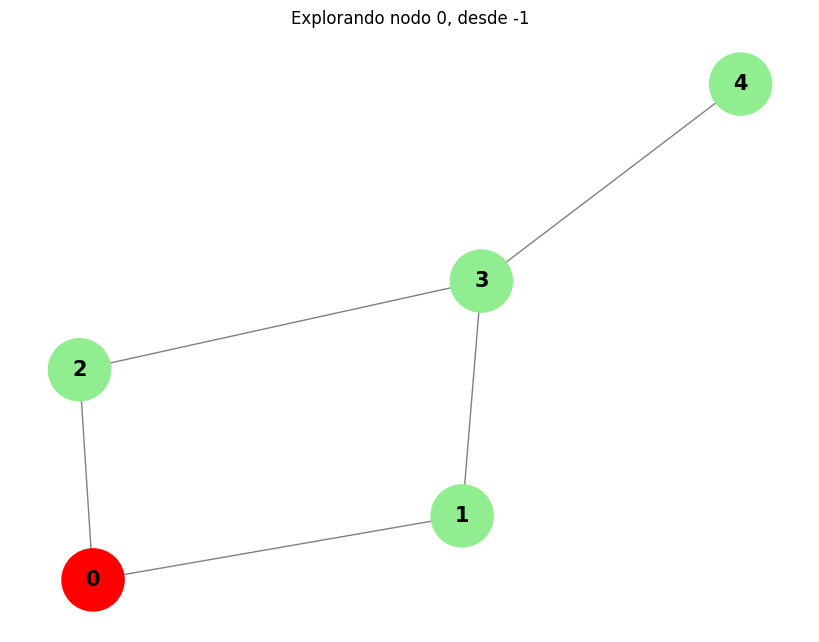

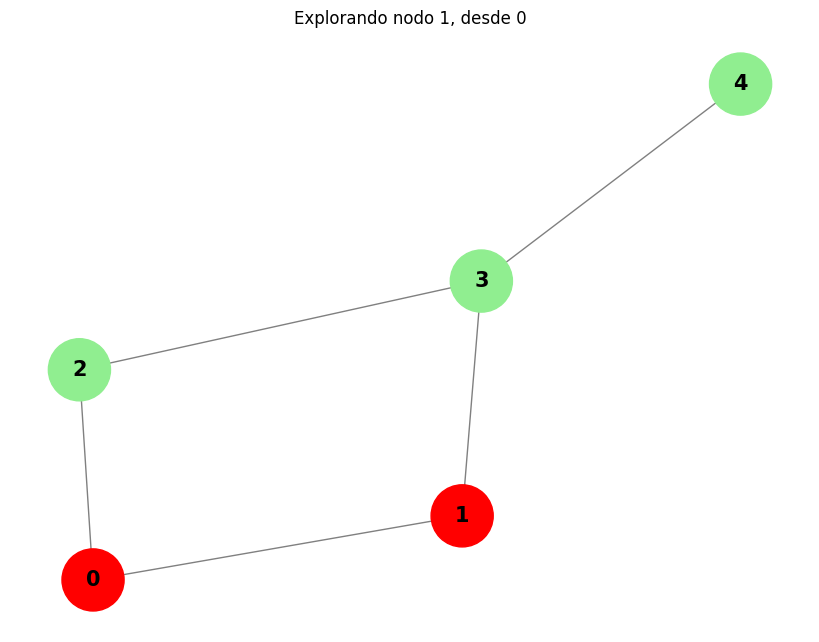

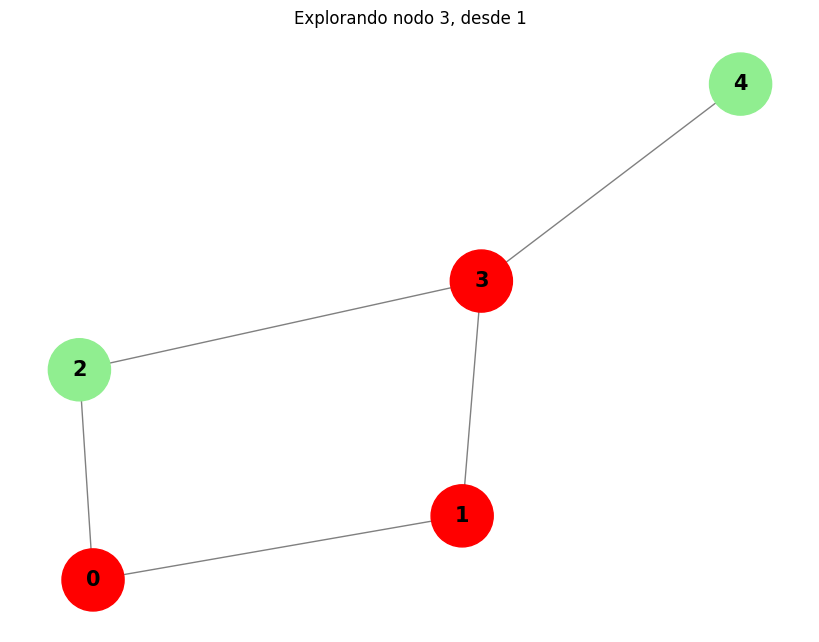

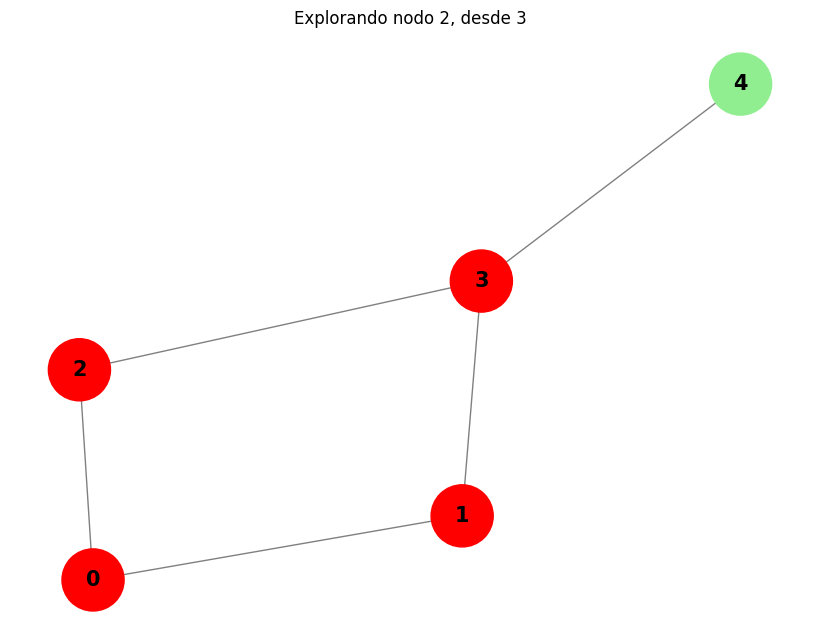

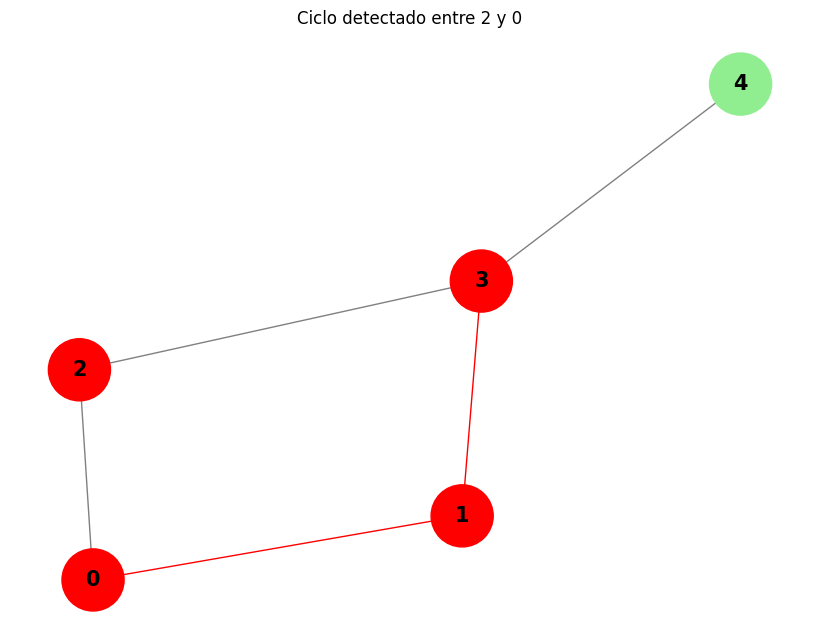

El grafo tiene ciclos.


True

In [15]:
# Función para detectar ciclos en un grafo no dirigido y visualizar el proceso
def is_cyclic_undirected_visual(graph):
    visited = set()
    G = nx.Graph()

    # Añadir nodos y aristas al grafo
    for node, neighbors in graph.items():
        for neighbor in neighbors:
            G.add_edge(node, neighbor)

    pos = nx.spring_layout(G)  # Layout para organizar el grafo

    # Función recursiva de DFS con visualización
    def dfs(node, parent):
        visited.add(node)
        
        # Visualizamos el grafo en su estado actual
        plt.figure(figsize=(8, 6))
        color_map = ['red' if n in visited else 'lightgreen' for n in G.nodes]
        nx.draw(G, pos, with_labels=True, node_color=color_map, node_size=2000, font_size=15, font_weight='bold', edge_color='gray')
        plt.title(f"Explorando nodo {node}, desde {parent}")
        plt.show()

        for neighbor in graph[node]:
            if neighbor not in visited:
                if dfs(neighbor, node):
                    return True
            elif neighbor != parent:
                # Si encontramos un ciclo, resaltamos la arista del ciclo
                plt.figure(figsize=(8, 6))
                color_map = ['red' if n in visited else 'lightgreen' for n in G.nodes]
                edge_colors = ['red' if (node == n or neighbor == n) else 'gray' for n in G.nodes]
                nx.draw(G, pos, with_labels=True, node_color=color_map, node_size=2000, font_size=15, font_weight='bold', edge_color=edge_colors)
                plt.title(f"Ciclo detectado entre {node} y {neighbor}")
                plt.show()
                return True
        return False

    # Llamamos a DFS desde cualquier nodo no visitado
    for node in graph:
        if node not in visited:
            if dfs(node, -1):  # -1 es el "padre" de la raíz
                print("El grafo tiene ciclos.")
                return True

    print("El grafo es acíclico.")
    return False

# Ejecutamos la función visual para detectar ciclos en el grafo
is_cyclic_undirected_visual(graph)


In [10]:

def is_cyclic_undirected(graph):
    visited = set() # Marca el nodo actual como visitado

    # Función recursiva de DFS
    def dfs(node, parent):  
        visited.add(node)  # Itera sobre cada vecino del nodo actual
        for neighbor in graph[node]: # Itera sobre cada vecino del nodo actual
            if neighbor not in visited:  # Si el vecino no ha sido visitado
                if dfs(neighbor, node):  # Llama recursivamente a DFS con el vecino como nuevo nodo y el actual como padre
                    return True
            elif neighbor != parent: # Si el vecino ya fue visitado y no es el padre del nodo actual
                return True # Hay un ciclo porque se ha regresado a un nodo visitado que no es el que lo llevó allí
        return False # Si se exploran todos los vecinos sin encontrar un ciclo, retorna False

    # Llamamos a DFS desde cualquier nodo no visitado
    for node in graph:
        if node not in visited:
            if dfs(node, -1):  # -1 es el "padre" de la raíz
                return True
    return False

# Verificamos si el grafo es acíclico
if is_cyclic_undirected(graph):
    print("El grafo tiene ciclos.")
else:
    print("El grafo es acíclico.")

El grafo tiene ciclos.



### Estrategia y código para grafos dirigidos (DAG):
Para grafos dirigidos, la detección de ciclos se puede hacer usando DFS y un conjunto para marcar los nodos en la pila de recursión.


In [19]:
# Grafo dirigido
directed_graph  = {
    0: [1],
    1: [2],
    2: [3],
    3: [4],
    4: [2]  # Este ciclo vuelve a 2
}


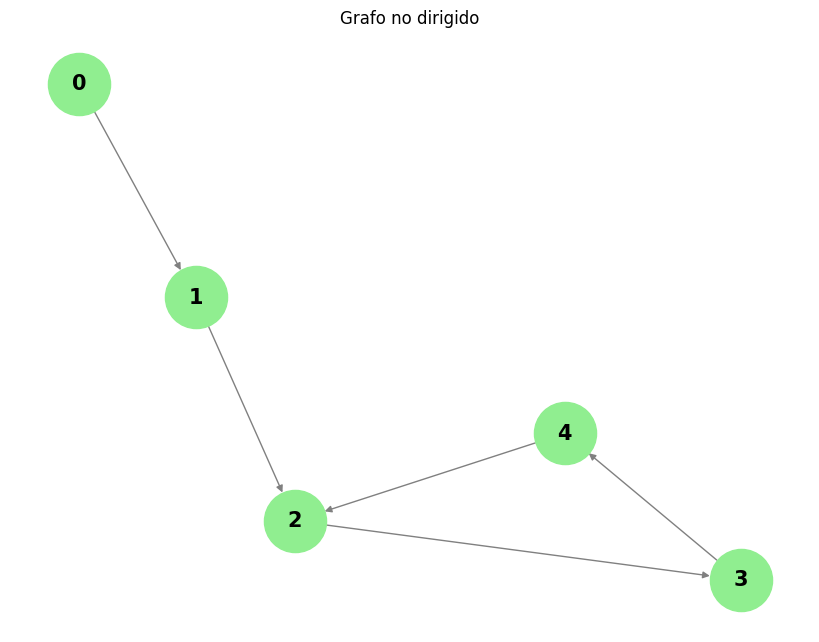

In [20]:
# Crear el grafo en NetworkX
G = nx.DiGraph()

# Añadir nodos y aristas al grafo
for node, neighbors in directed_graph.items():
    for neighbor in neighbors:
        G.add_edge(node, neighbor)

# Dibujar el grafo no dirigido
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G)  # Layout para organizar el grafo
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=2000, font_size=15, font_weight='bold', edge_color='gray')
plt.title("Grafo no dirigido")
plt.show()

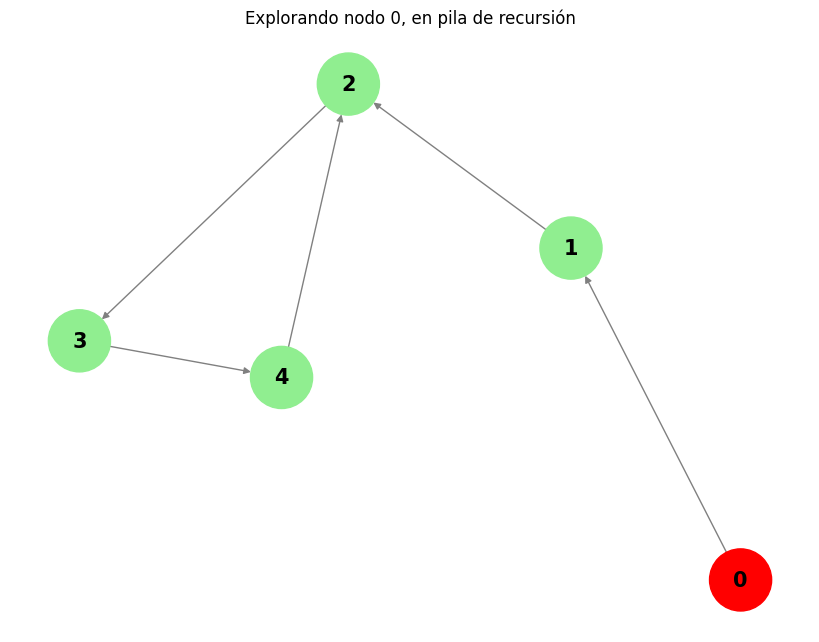

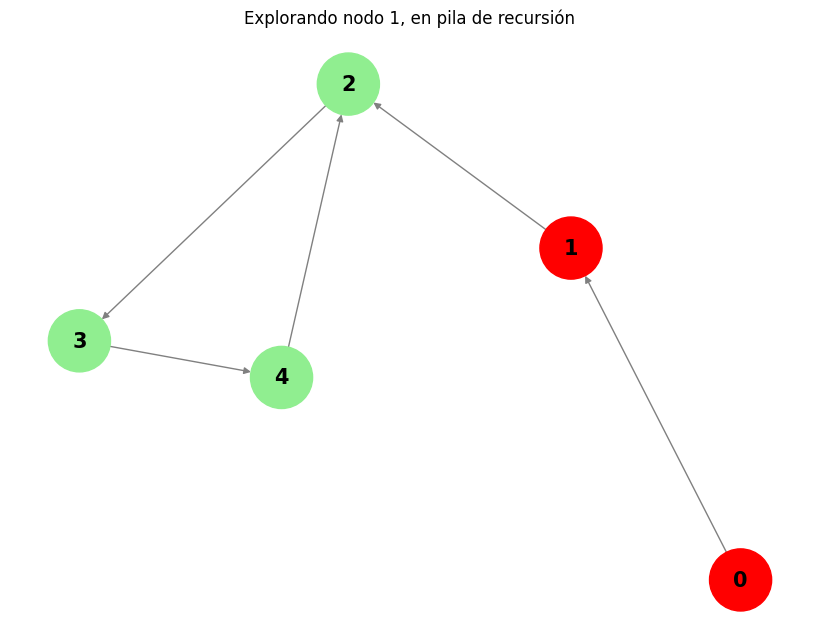

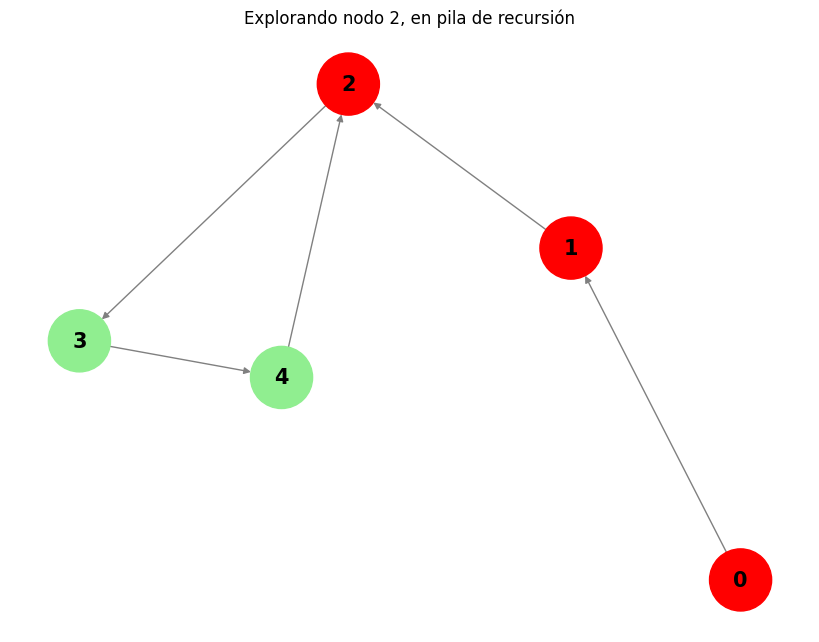

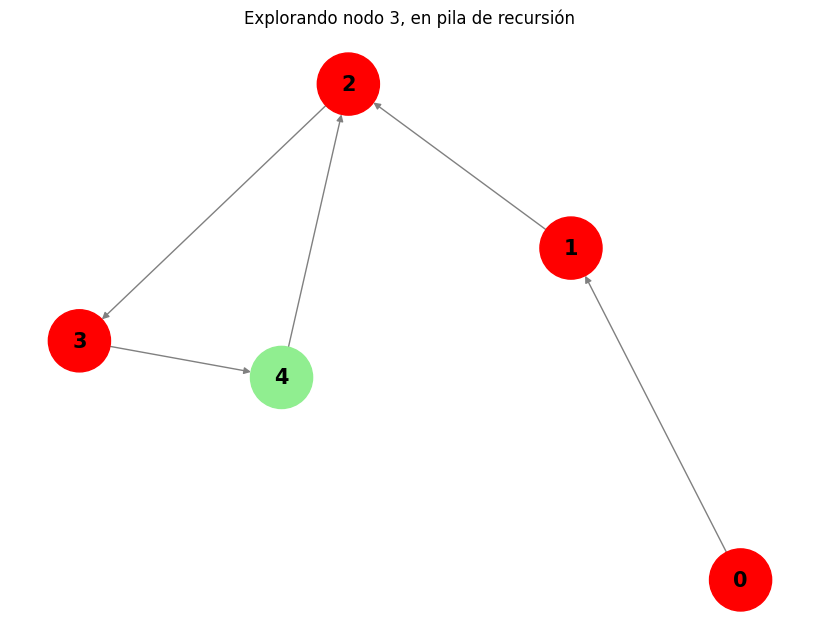

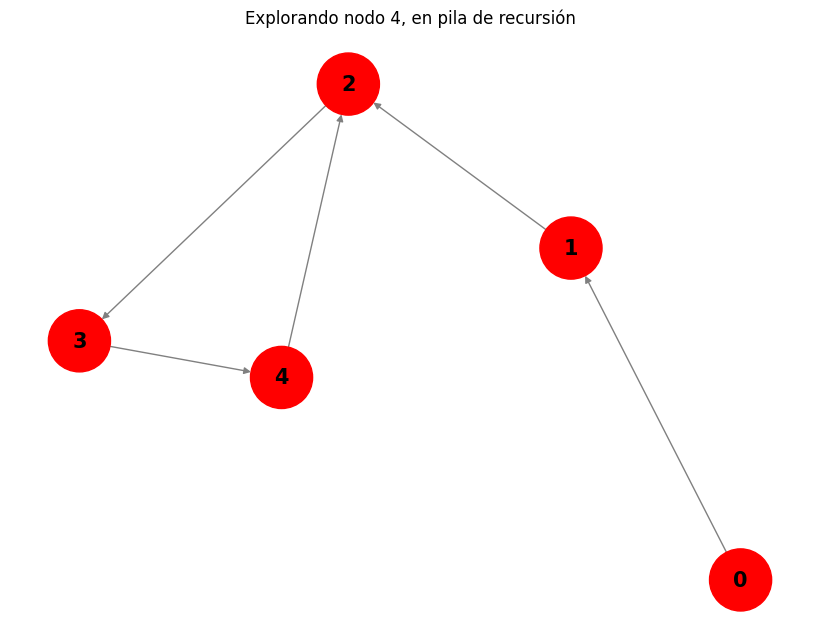

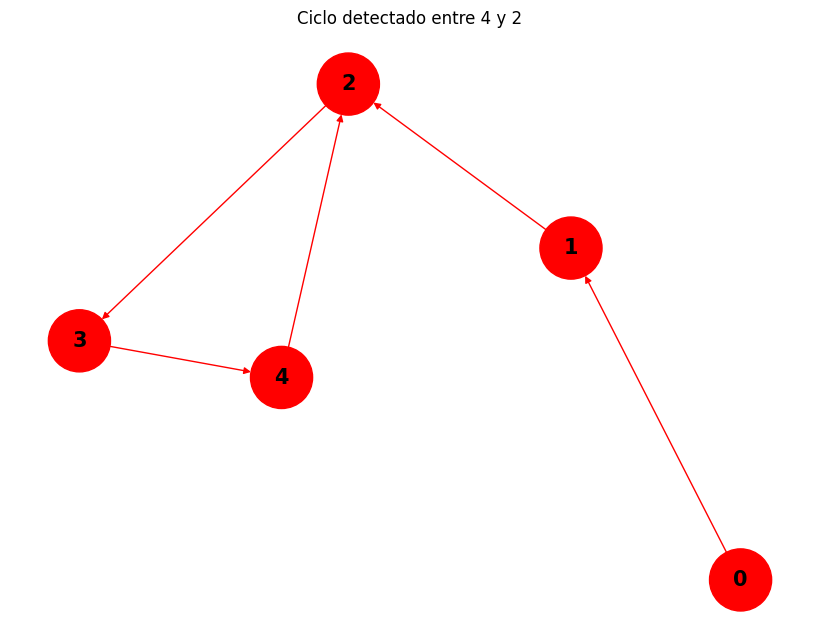

El grafo dirigido tiene ciclos.


True

In [21]:

# Función para detectar ciclos en un grafo dirigido y visualizar el proceso
def is_cyclic_directed_visual(graph):
    visited = set()
    rec_stack = set()  # Pila de recursión para detectar ciclos
    G = nx.DiGraph()  # Grafo dirigido

    # Añadir nodos y aristas al grafo dirigido
    for node, neighbors in graph.items():
        for neighbor in neighbors:
            G.add_edge(node, neighbor)

    pos = nx.spring_layout(G)  # Layout para organizar el grafo

    # Función recursiva de DFS con visualización
    def dfs(node):
        visited.add(node)
        rec_stack.add(node)
        
        # Visualizamos el grafo en su estado actual
        plt.figure(figsize=(8, 6))
        color_map = ['red' if n in rec_stack else 'lightgreen' for n in G.nodes]
        nx.draw(G, pos, with_labels=True, node_color=color_map, node_size=2000, font_size=15, font_weight='bold', edge_color='gray')
        plt.title(f"Explorando nodo {node}, en pila de recursión")
        plt.show()

        for neighbor in graph[node]:
            if neighbor not in visited:
                if dfs(neighbor):
                    return True
            elif neighbor in rec_stack:
                # Si encontramos un ciclo, resaltamos la arista del ciclo
                plt.figure(figsize=(8, 6))
                color_map = ['red' if n in rec_stack else 'lightgreen' for n in G.nodes]
                edge_colors = ['red' if G.has_edge(node, neighbor) else 'gray' for n in G.nodes]
                nx.draw(G, pos, with_labels=True, node_color=color_map, node_size=2000, font_size=15, font_weight='bold', edge_color=edge_colors)
                plt.title(f"Ciclo detectado entre {node} y {neighbor}")
                plt.show()
                return True

        rec_stack.remove(node)
        return False

    # Llamamos a DFS desde cualquier nodo no visitado
    for node in graph:
        if node not in visited:
            if dfs(node):
                print("El grafo dirigido tiene ciclos.")
                return True

    print("El grafo dirigido es acíclico.")
    return False

# Ejecutamos la función visual para detectar ciclos en el grafo dirigido
is_cyclic_directed_visual(directed_graph)


In [14]:

def is_cyclic_directed(graph):
    visited = set()
    rec_stack = set()  # Pila de recursión para detectar ciclos

    # Función recursiva de DFS
    def dfs(node):
        visited.add(node)
        rec_stack.add(node)

        for neighbor in graph[node]:
            if neighbor not in visited:
                if dfs(neighbor):
                    return True
            elif neighbor in rec_stack:
                return True

        rec_stack.remove(node)
        return False

    # Llamamos a DFS desde cualquier nodo no visitado
    for node in graph:
        if node not in visited:
            if dfs(node):
                return True
    return False

# Verificamos si el grafo dirigido tiene ciclos
if is_cyclic_directed(graph_directed):
    print("El grafo dirigido tiene ciclos.")
else:
    print("El grafo dirigido es acíclico.")

El grafo dirigido tiene ciclos.



###  Determinar si un Grafo es Fuertemente Conectado

#### 1. Definición:
Un grafo dirigido es **fuertemente conectado** si para cualquier par de nodos \( u \) y \( v \), hay:
- Un camino dirigido de \( u \) a \( v \),
- Y un camino dirigido de \( v \) a \( u \).

#### 2. Algoritmo Basado en Búsqueda en Profundidad (DFS)
El siguiente es un algoritmo común para verificar si un grafo dirigido es fuertemente conectado utilizando **DFS**:

1. Realizar una búsqueda en profundidad desde un nodo arbitrario (por ejemplo, el nodo 0).
2. Si no se alcanzan todos los nodos, el grafo no es fuertemente conectado.
3. Si se alcanzan todos los nodos, invertir las direcciones de todas las aristas (grafo transpuesto).
4. Realizar otra búsqueda en profundidad desde el mismo nodo en el grafo transpuesto.
5. Si no se alcanzan todos los nodos en esta segunda búsqueda, el grafo no es fuertemente conectado. Si se alcanzan, entonces el grafo es fuertemente conectado.



### Pseudocódigo:

```
Algoritmo esFuertementeConectado(Grafo G)
1. Realizar DFS desde un nodo arbitrario (por ejemplo, el nodo 0):
    Si no todos los nodos son alcanzados:
        devolver FALSO
2. Calcular el grafo transpuesto G^T (invirtiendo las direcciones de todas las aristas)
3. Realizar DFS desde el mismo nodo en G^T:
    Si no todos los nodos son alcanzados:
        devolver FALSO
4. Si se alcanzaron todos los nodos en ambas búsquedas, devolver VERDADERO
```



---

### Implementación en Python:


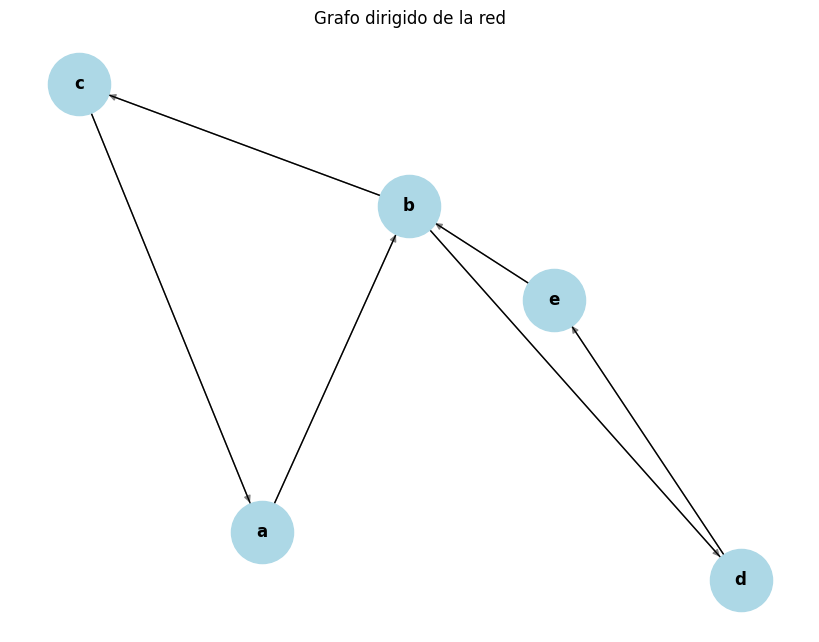

El grafo es fuertemente conectado.


In [4]:
import matplotlib.pyplot as plt
import networkx as nx

# Función para realizar DFS y verificar si todos los nodos son alcanzados
def dfs(graph, node, visited):
    visited.add(node)
    for neighbor in graph.neighbors(node):
        if neighbor not in visited:
            dfs(graph, neighbor, visited)

# Función para verificar si un grafo es fuertemente conectado
def es_fuertemente_conectado(graph):
    # Paso 1: DFS en el grafo original desde un nodo arbitrario
    start_node = list(graph.nodes)[0]
    visited = set()
    dfs(graph, start_node, visited)
    
    # Si no se alcanzaron todos los nodos, el grafo no es fuertemente conectado
    if len(visited) != len(graph.nodes):
        return False
    
    # Paso 2: Invertir las direcciones de las aristas (grafo transpuesto)
    grafo_transpuesto = graph.reverse(copy=True)
    
    # Paso 3: DFS en el grafo transpuesto desde el mismo nodo
    visited_transposed = set()
    dfs(grafo_transpuesto, start_node, visited_transposed)
    
    # Si no se alcanzaron todos los nodos en el grafo transpuesto, no es fuertemente conectado
    if len(visited_transposed) != len(graph.nodes):
        return False
    
    # Si se alcanzaron todos los nodos en ambas búsquedas, el grafo es fuertemente conectado
    return True

# Crear un grafo dirigido de ejemplo
G = nx.DiGraph()
edges = [('a', 'b'), ('b', 'c'), ('c', 'a'), ('b', 'd'), ('d', 'e'), ('e', 'b')]
G.add_edges_from(edges)

# Crear un grafo dirigido de ejemplo
G = nx.DiGraph()
edges = [('a', 'b'), ('b', 'c'), ('c', 'a'), ('b', 'd'), ('d', 'e'), ('e', 'b')]
G.add_edges_from(edges)

# Visualizar el grafo
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=12, font_weight='bold', edge_color='gray')
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color='black', arrows=True)
plt.title("Grafo dirigido de la red")
plt.show()


# Verificar si el grafo es fuertemente conectado
if es_fuertemente_conectado(G):
    print("El grafo es fuertemente conectado.")
else:
    print("El grafo NO es fuertemente conectado.")



1. **Función `dfs(graph, node, visited)`**:
   - Realiza una búsqueda en profundidad (DFS) desde un nodo dado y marca todos los nodos alcanzados como visitados.

2. **Función `es_fuertemente_conectado(graph)`**:
   - Realiza el primer DFS en el grafo original para verificar si todos los nodos son alcanzados.
   - Luego calcula el **grafo transpuesto** invirtiendo las aristas.
   - Realiza un segundo DFS en el grafo transpuesto desde el mismo nodo.
   - Si en ambos pasos se alcanzan todos los nodos, el grafo es fuertemente conectado.

3. **Verificación de conectividad**:
   - Si alguna de las dos búsquedas (en el grafo original o transpuesto) no alcanza todos los nodos, el grafo no es fuertemente conectado.





### Aplicación en Redes de Transporte

El concepto de **fuertemente conectado** es importante en aplicaciones como las **redes de transporte**. Por ejemplo:
- En una red de carreteras, una red fuertemente conectada significa que es posible viajar entre cualquier par de ciudades en ambas direcciones.
- En un sistema de mensajería, una red fuertemente conectada garantiza que los mensajes puedan ser enviados y recibidos entre cualquier par de nodos sin problemas de conexión unidireccional.

